# 🤖 Taller de Aprendizaje Supervisado — Detección de Churn de Clientes

**Curso:** Aprendizaje Automático  
**Dataset:** `datos_clientes.csv` — Métricas RFM y comportamiento de compra  
**Objetivo:** Predecir si un cliente abandonará (churn = 1) usando clasificadores supervisados

---

### Modelos implementados
| Modelo | Tipo | Hiperparámetro clave |
|--------|------|----------------------|
| Árbol de Decisión | Clasificación | `max_depth`, `min_samples_leaf` |
| SVM | Clasificación | `kernel`, `C` |
| Random Forest | Clasificación (ensemble) | `n_estimators`, `max_depth` |

### Flujo de trabajo
```
Carga → EDA → Preprocesamiento → Modelos → Evaluación → Conclusiones
```


---
## 0. Importaciones y Configuración

In [41]:
# ── Librerías estándar ─────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocesamiento
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Modelos
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# Métricas
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, auc,
    precision_score, recall_score, f1_score, accuracy_score
)

# Configuración visual
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (10, 5)

print('✅ Librerías importadas correctamente.')


✅ Librerías importadas correctamente.


---
## 1. Carga del Dataset

In [32]:

from google.colab import drive
drive.mount('/content/drive')

RUTA = '/content/drive/MyDrive/Colab Notebooks/UEES/datos_clientes.csv'

df = pd.read_csv(RUTA)
print(f'✅ Dataset cargado: {df.shape[0]} filas × {df.shape[1]} columnas')
df.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Dataset cargado: 200 filas × 43 columnas


,recencia_dias,num_facturas_12m,meses_con_compra_12m,meses_con_compra_24m,pct_regularidad,neto_12m,bruto_12m,rentab_12m,costo_12m,unidades_12m,...,m_score,rfm_score,segmento_rfm,etapa_ciclo_vida,tendencia,pareto_v,pareto_r,medio_predominante,forma_pago,churn
0,214,62,6,17,47.2000,72838.3900,142146.9600,26439.8485,46398.5415,10573.0000,...,5,4.1000,EN_RIESGO,EN_RIESGO,DECAYENDO,A,A,Tradicional,Crédito 90 días 3P (30-60-90),1
1,137,8,5,11,47.8000,3478.6200,6381.7500,1226.1167,2252.5033,339.0000,...,4,3.7000,LEAL_ALTO_VALOR,RIESGO_TEMPRANO,DECAYENDO,C,C,Tradicional,Crédito 60 días 2P (30-60),0
2,13,10,7,9,25.7000,8301.5300,12211.1700,4180.7701,4120.7599,182.0000,...,5,5.0000,CAMPEON,MADURO,CRECIENDO,C,B,Tradicional,Contado - Efectivo,0
3,60,1,1,5,14.3000,389.6300,556.6100,285.3743,104.2557,3.0000,...,3,3.0000,NUEVO_PROMETEDOR,MADURO,SIN_HISTORICO,C,C,Tradicional,Crédito 30 días,0
4,319,1,1,1,10.0000,117.6000,147.0000,69.2454,48.3546,1.0000,...,2,1.4000,HIBERNANDO,EN_RIESGO,DECAYENDO,C,C,Tradicional,Contado - Efectivo,1


---
## 2. Análisis Exploratorio de Datos (EDA)

### 2.1 Descripción general del dataset

El dataset contiene **métricas de comportamiento de clientes** calculadas a partir de datos de ventas:
- **Variables RFM**: Recencia (días desde última compra), Frecuencia (facturas), Monetario (neto 12m)
- **Variables de rentabilidad**: margen, descuento, devoluciones
- **Segmentos categóricos**: segmento RFM, etapa del ciclo de vida, tendencia, forma de pago
- **Variable objetivo**: `churn` (1 = cliente perdido, 0 = activo)


In [6]:
# ── 2.1 Información general ────────────────────────────────────────────────────
print("=== INFORMACIÓN DEL DATASET ===")
print(df.info())
print()
print("=== ESTADÍSTICAS DESCRIPTIVAS (numéricas) ===")
df.describe().T


=== INFORMACIÓN DEL DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 43 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   recencia_dias         200 non-null    int64  
 1   num_facturas_12m      200 non-null    int64  
 2   meses_con_compra_12m  200 non-null    int64  
 3   meses_con_compra_24m  200 non-null    int64  
 4   pct_regularidad       196 non-null    float64
 5   neto_12m              200 non-null    float64
 6   bruto_12m             200 non-null    float64
 7   rentab_12m            200 non-null    float64
 8   costo_12m             200 non-null    float64
 9   unidades_12m          200 non-null    float64
 10  ticket_medio_neto     200 non-null    float64
 11  ticket_medio_bruto    200 non-null    float64
 12  pct_margen            200 non-null    float64
 13  pct_descuento_real    200 non-null    float64
 14  devuelto_12m          200 non-null    floa

,count,mean,std,min,25%,50%,75%,max
recencia_dias,200.0000,131.6800,119.6833,0.0000,17.7500,96.0000,221.0000,364.0000
num_facturas_12m,200.0000,15.6000,46.4557,1.0000,1.0000,2.0000,9.0000,520.0000
meses_con_compra_12m,200.0000,3.4550,3.7306,1.0000,1.0000,1.0000,5.0000,13.0000
meses_con_compra_24m,200.0000,6.0150,7.4297,1.0000,1.0000,2.0000,8.0000,25.0000
pct_regularidad,196.0000,34.7658,31.2819,2.8000,10.7000,23.5000,50.0000,200.0000
neto_12m,200.0000,20960.1764,93918.3973,0.9200,178.0725,807.6400,6067.6325,1172969.2100
bruto_12m,200.0000,37349.5503,190910.6968,1.2600,253.6275,1106.0250,10198.6325,2526799.8500
rentab_12m,200.0000,7730.3489,31231.4831,0.4640,81.8049,378.4531,2784.1688,380358.8544
costo_12m,200.0000,13229.8275,63479.4052,0.0000,76.6343,332.5618,2894.0410,792610.3556
unidades_12m,200.0000,2595.2857,13799.3118,1.0000,5.0000,23.5000,181.2500,138165.0500


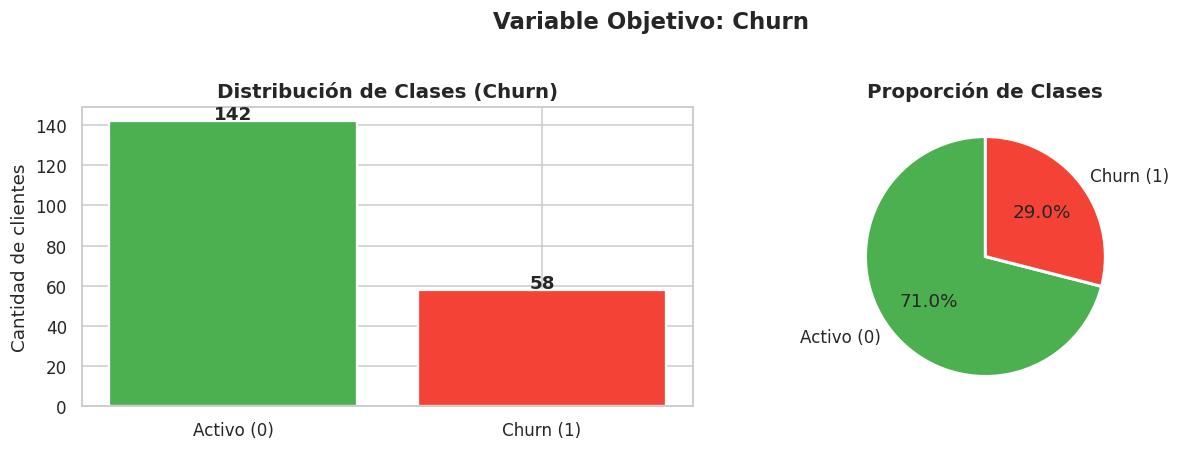


📊 Ratio de desbalance: 2.45:1 (Activo:Churn)


In [7]:
# ── 2.2 Distribución de la variable objetivo ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Conteo
churn_counts = df['churn'].value_counts()
axes[0].bar(['Activo (0)', 'Churn (1)'], churn_counts.values,
            color=['#4CAF50', '#F44336'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribución de Clases (Churn)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Cantidad de clientes')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

# Porcentaje
axes[1].pie(churn_counts.values, labels=['Activo (0)', 'Churn (1)'],
            autopct='%1.1f%%', colors=['#4CAF50', '#F44336'],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporción de Clases', fontsize=13, fontweight='bold')

plt.suptitle('Variable Objetivo: Churn', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('01_distribucion_churn.png', bbox_inches='tight', dpi=120)
plt.show()
print(f"\n📊 Ratio de desbalance: {churn_counts[0]/churn_counts[1]:.2f}:1 (Activo:Churn)")


In [8]:
# ── 2.3 Análisis de nulos ──────────────────────────────────────────────────────
nulos = df.isnull().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)

print("=== COLUMNAS CON VALORES NULOS ===")
print(nulos.to_frame('nulos').assign(porcentaje=lambda x: (x['nulos']/len(df)*100).round(2)))


=== COLUMNAS CON VALORES NULOS ===
                    nulos  porcentaje
pct_tendencia          65     32.5000
pct_regularidad         4      2.0000
rentab_media_anual      4      2.0000
clv_proyectado_2a       4      2.0000


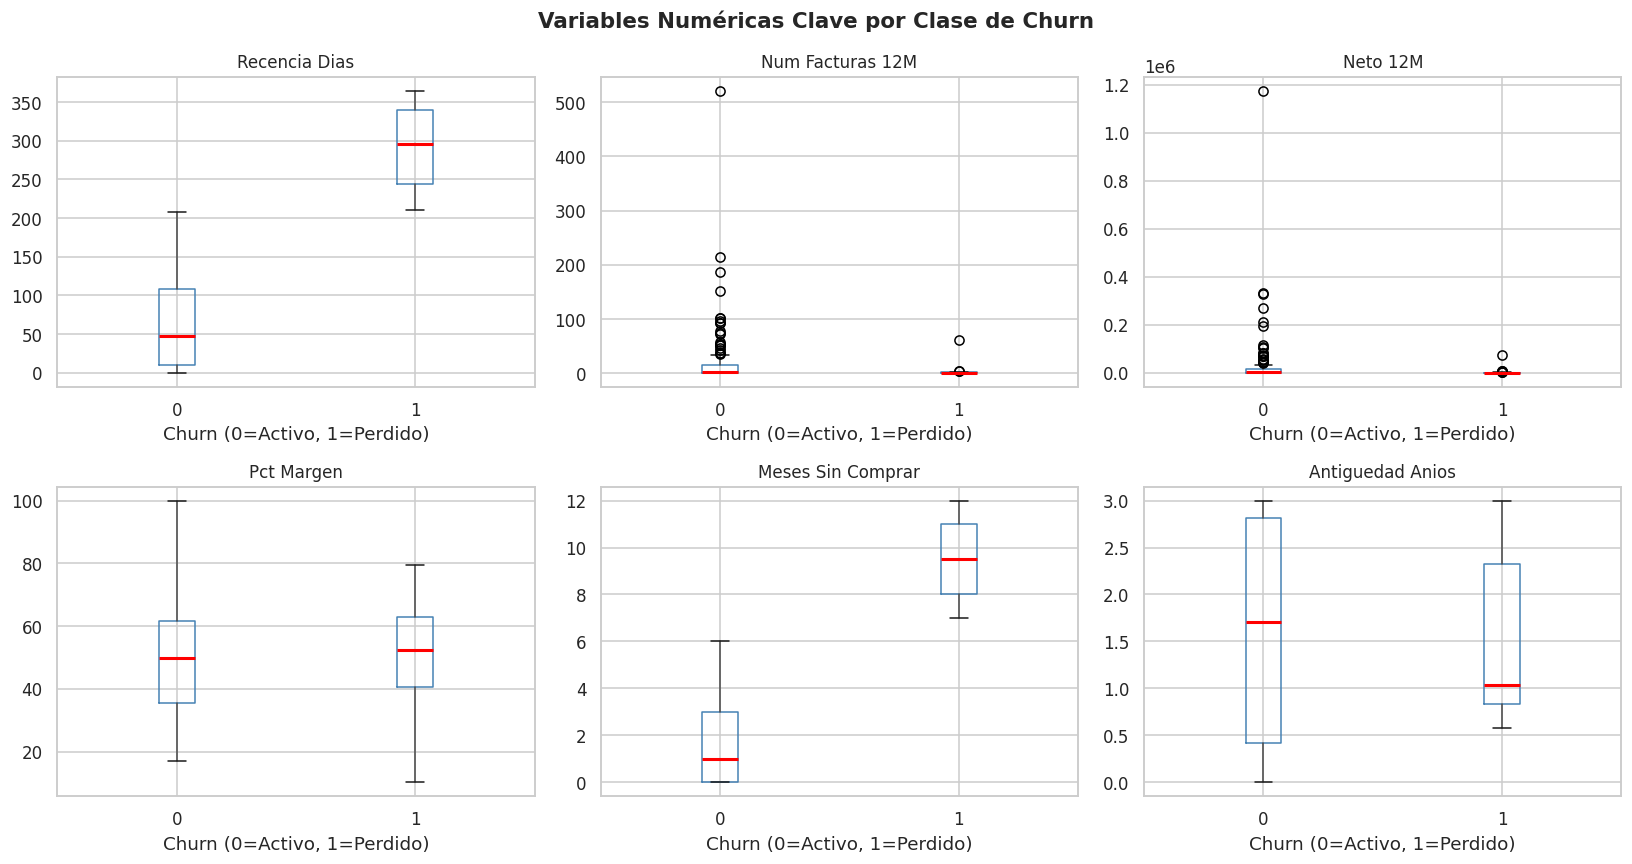

In [9]:
# ── 2.4 Visualización de variables clave vs Churn ──────────────────────────────
vars_clave = ['recencia_dias', 'num_facturas_12m', 'neto_12m',
              'pct_margen', 'meses_sin_comprar', 'antiguedad_anios']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, var in enumerate(vars_clave):
    df.boxplot(column=var, by='churn', ax=axes[i],
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(var.replace('_', ' ').title(), fontsize=11)
    axes[i].set_xlabel('Churn (0=Activo, 1=Perdido)')
    axes[i].set_ylabel('')

plt.suptitle('Variables Numéricas Clave por Clase de Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('02_boxplots_churn.png', bbox_inches='tight', dpi=120)
plt.show()


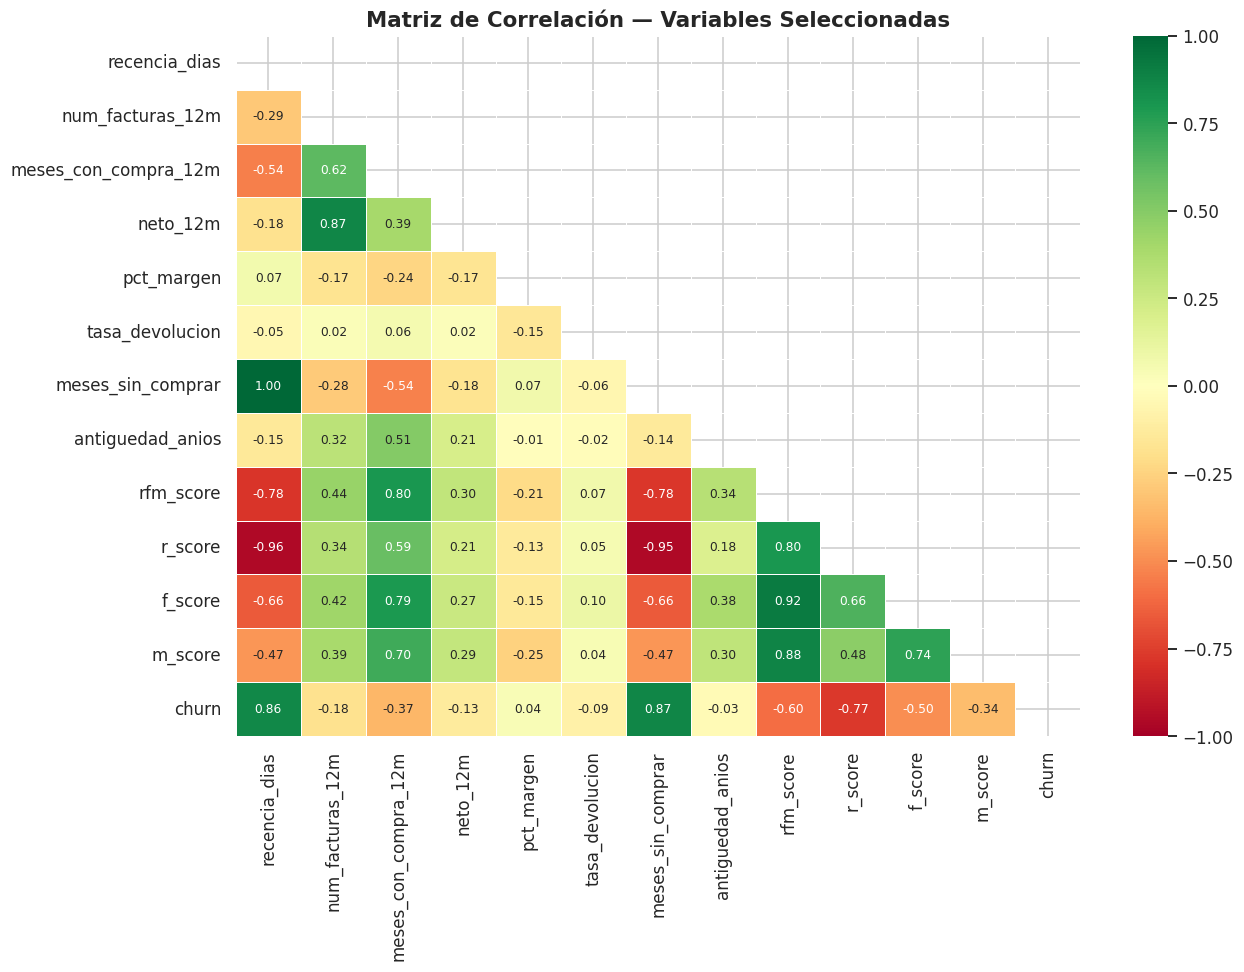

In [31]:
# ── 2.5 Matriz de correlación (variables numéricas relevantes) ────────────────
cols_corr = ['recencia_dias', 'num_facturas_12m', 'meses_con_compra_12m',
             'neto_12m', 'pct_margen', 'tasa_devolucion',
             'meses_sin_comprar', 'antiguedad_anios', 'rfm_score',
             'r_score', 'f_score', 'm_score', 'churn']

corr_matrix = df[cols_corr].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.5, annot_kws={'size': 8})
plt.title('Matriz de Correlación — Variables Seleccionadas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('03_correlacion.png', bbox_inches='tight', dpi=120)
plt.show()


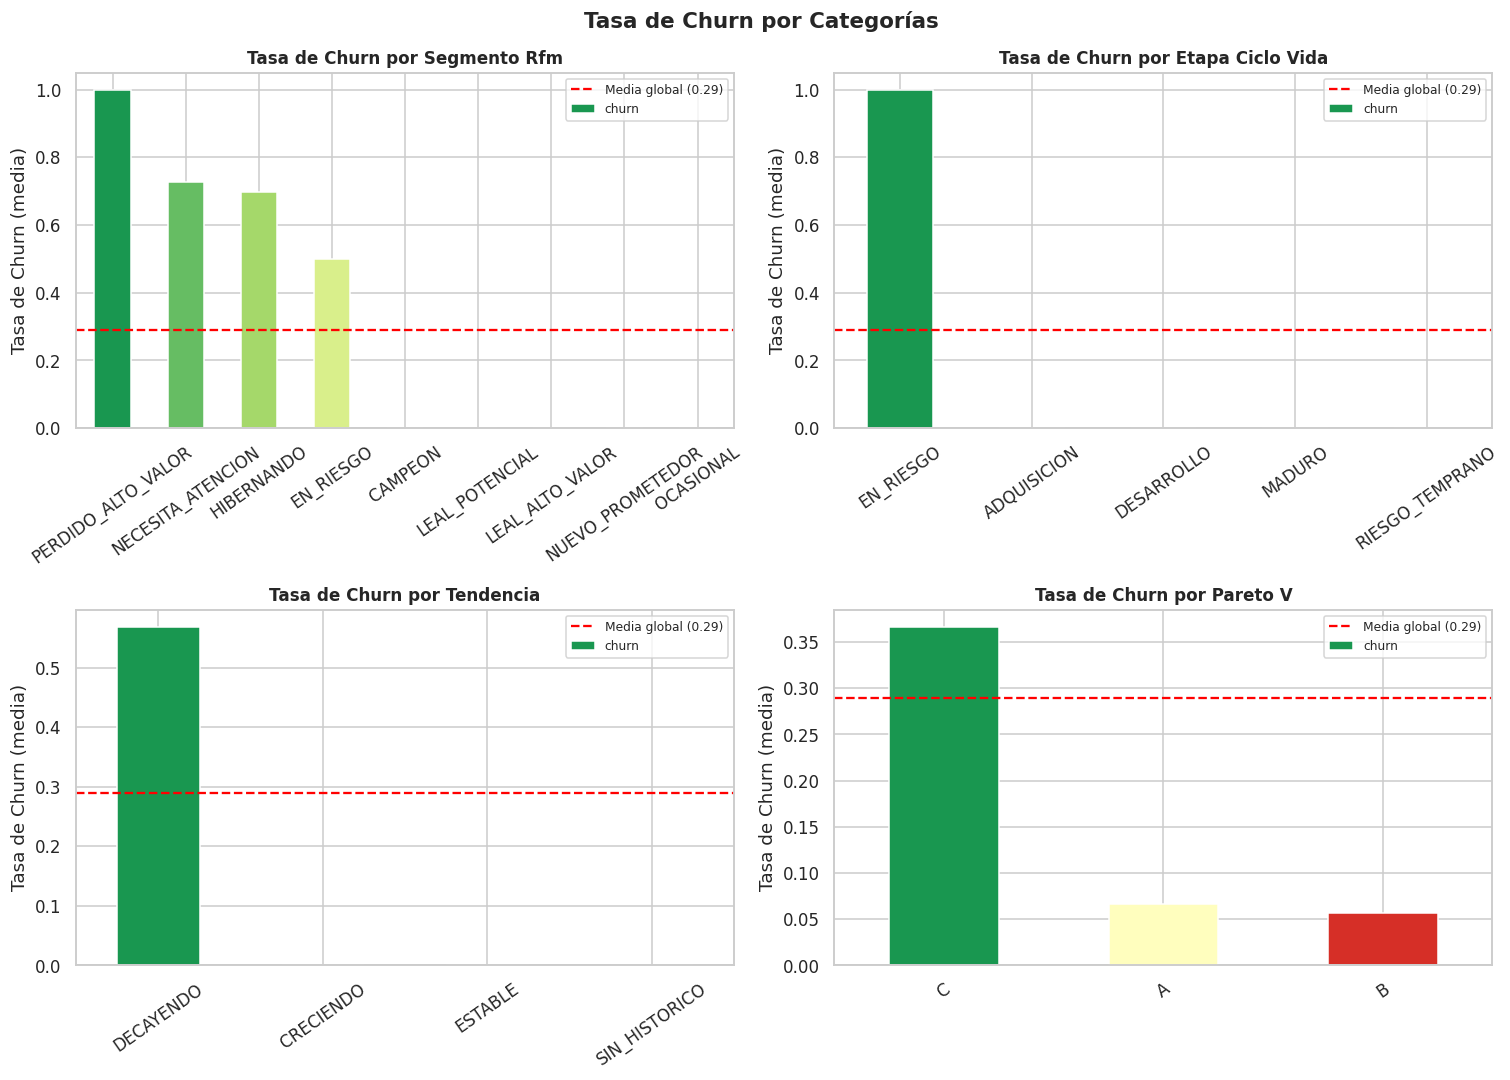

In [11]:
# ── 2.6 Variables categóricas vs Churn ────────────────────────────────────────
cat_vars = ['segmento_rfm', 'etapa_ciclo_vida', 'tendencia', 'pareto_v']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, var in enumerate(cat_vars):
    tbl = df.groupby(var)['churn'].mean().sort_values(ascending=False)
    colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(tbl)))
    tbl.plot(kind='bar', ax=axes[i], color=colors, edgecolor='white')
    axes[i].set_title(f'Tasa de Churn por {var.replace("_"," ").title()}',
                      fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Tasa de Churn (media)')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=35)
    axes[i].axhline(df['churn'].mean(), color='red', linestyle='--',
                    label=f'Media global ({df["churn"].mean():.2f})')
    axes[i].legend(fontsize=8)

plt.suptitle('Tasa de Churn por Categorías', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('04_cat_vs_churn.png', bbox_inches='tight', dpi=120)
plt.show()


---
## 3. Preprocesamiento

### Justificación de decisiones

| Decisión | Justificación |
|----------|--------------|
| Eliminar `prob_churn` | Correlación >0.96 con `churn` → fuga de información (data leakage) |
| Eliminar `medio_predominante` | Un solo valor único → sin poder predictivo |
| Imputar con mediana | Robusta a outliers; solo 4–65 nulos (<33%) |
| Codificación One-Hot | Variables nominales sin orden intrínseco |
| Escalado StandardScaler | SVM y comparaciones son sensibles a la escala |
| Split 80/20 con stratify | Preserva el ratio de clases en ambos subconjuntos |


In [33]:
# ── 3.1 Selección de features ──────────────────────────────────────────────────

# Variables a excluir:
#   prob_churn  → data leakage (correlación 0.96 con target)
#   medio_predominante → sin variabilidad (1 solo valor)
#   clv_proyectado_2a, rentab_media_anual → también derivadas de churn potencialmente

EXCLUIR = ['prob_churn', 'medio_predominante', 'clv_proyectado_2a', 'rentab_media_anual']

TARGET = 'churn'

X = df.drop(columns=[TARGET] + EXCLUIR)
y = df[TARGET]

# Separar numéricas y categóricas
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f"✅ Features numéricas: {len(num_cols)}")
print(f"✅ Features categóricas: {len(cat_cols)} → {cat_cols}")
print(f"✅ Variable objetivo — Distribución: {y.value_counts().to_dict()}")


✅ Features numéricas: 32
✅ Features categóricas: 6 → ['segmento_rfm', 'etapa_ciclo_vida', 'tendencia', 'pareto_v', 'pareto_r', 'forma_pago']
✅ Variable objetivo — Distribución: {0: 142, 1: 58}


In [34]:
# ── 3.2 Pipeline de preprocesamiento ───────────────────────────────────────────
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Pipeline numérico: imputar mediana + escalar
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline categórico: imputar moda + One-Hot
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Transformador combinado
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

print("✅ Pipeline de preprocesamiento definido.")


✅ Pipeline de preprocesamiento definido.


In [17]:
# ── 3.3 División entrenamiento / prueba (80/20) ────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y        # preservar ratio de clases
)

print(f"Entrenamiento: {X_train.shape[0]} muestras")
print(f"Prueba:        {X_test.shape[0]} muestras")
print(f"\nDistribución churn en Train: {y_train.value_counts().to_dict()}")
print(f"Distribución churn en Test:  {y_test.value_counts().to_dict()}")


Entrenamiento: 160 muestras
Prueba:        40 muestras

Distribución churn en Train: {0: 114, 1: 46}
Distribución churn en Test:  {0: 28, 1: 12}


---
## 4. Implementación de Clasificadores

Entrenamos tres modelos supervisados dentro de un pipeline `sklearn` que aplica
el preprocesamiento automáticamente. Esto evita fuga de información del test set.


In [18]:
# ── Función utilitaria de evaluación ───────────────────────────────────────────
def evaluar_modelo(nombre, modelo, X_tr, y_tr, X_te, y_te):
    """Entrena, evalúa y retorna métricas de un modelo."""
    modelo.fit(X_tr, y_tr)
    y_pred = modelo.predict(X_te)

    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec  = recall_score(y_te, y_pred, zero_division=0)
    f1   = f1_score(y_te, y_pred, zero_division=0)
    cv   = cross_val_score(modelo, X_tr, y_tr, cv=5, scoring='f1').mean()

    print(f"\n{'='*55}")
    print(f"  {nombre}")
    print(f"{'='*55}")
    print(classification_report(y_te, y_pred, target_names=['Activo', 'Churn']))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Matriz de confusión
    cm = confusion_matrix(y_te, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Activo', 'Churn'])
    disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
    axes[0].set_title(f'Matriz de Confusión\n{nombre}', fontweight='bold')

    # Curva ROC
    if hasattr(modelo, 'predict_proba'):
        y_prob = modelo.predict_proba(X_te)[:, 1]
    else:
        y_prob = modelo.decision_function(X_te)
    fpr, tpr, _ = roc_curve(y_te, y_prob)
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color='steelblue', lw=2,
                 label=f'AUC = {roc_auc:.3f}')
    axes[1].plot([0,1],[0,1],'k--', lw=1)
    axes[1].set_xlabel('Tasa de Falsos Positivos')
    axes[1].set_ylabel('Tasa de Verdaderos Positivos')
    axes[1].set_title(f'Curva ROC — {nombre}', fontweight='bold')
    axes[1].legend()
    plt.tight_layout()
    plt.savefig(f'metricas_{nombre.replace(" ","_")}.png', bbox_inches='tight', dpi=110)
    plt.show()

    return {
        'Modelo': nombre,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4),
        'F1 CV-5': round(cv, 4),
        'AUC-ROC': round(roc_auc, 4)
    }

resultados = []
print("✅ Función de evaluación lista.")


✅ Función de evaluación lista.


### 4.1 Modelo 1 — Árbol de Decisión

**Justificación:** Modelo interpretable, sin necesidad de escalado (aunque se incluye en el pipeline por uniformidad). Permite visualizar las reglas de decisión. Sensible a overfitting sin poda.

**Hiperparámetros ajustados:**
- `max_depth=5` → limita la profundidad para evitar sobreajuste
- `min_samples_leaf=5` → mínimo de muestras en hoja
- `class_weight='balanced'` → compensa el desbalance de clases



  Árbol de Decisión
              precision    recall  f1-score   support

      Activo       1.00      1.00      1.00        28
       Churn       1.00      1.00      1.00        12

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



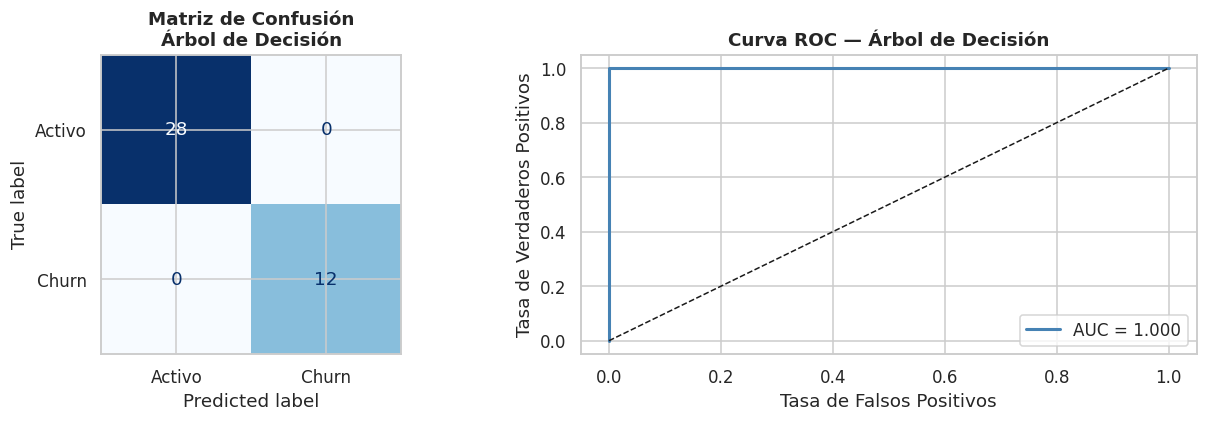

In [19]:
# ── Modelo 1: Árbol de Decisión ────────────────────────────────────────────────
dt_model = Pipeline([
    ('prep', preprocessor),
    ('clf', DecisionTreeClassifier(
        max_depth=5,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42
    ))
])

res_dt = evaluar_modelo("Árbol de Decisión", dt_model,
                         X_train, y_train, X_test, y_test)
resultados.append(res_dt)


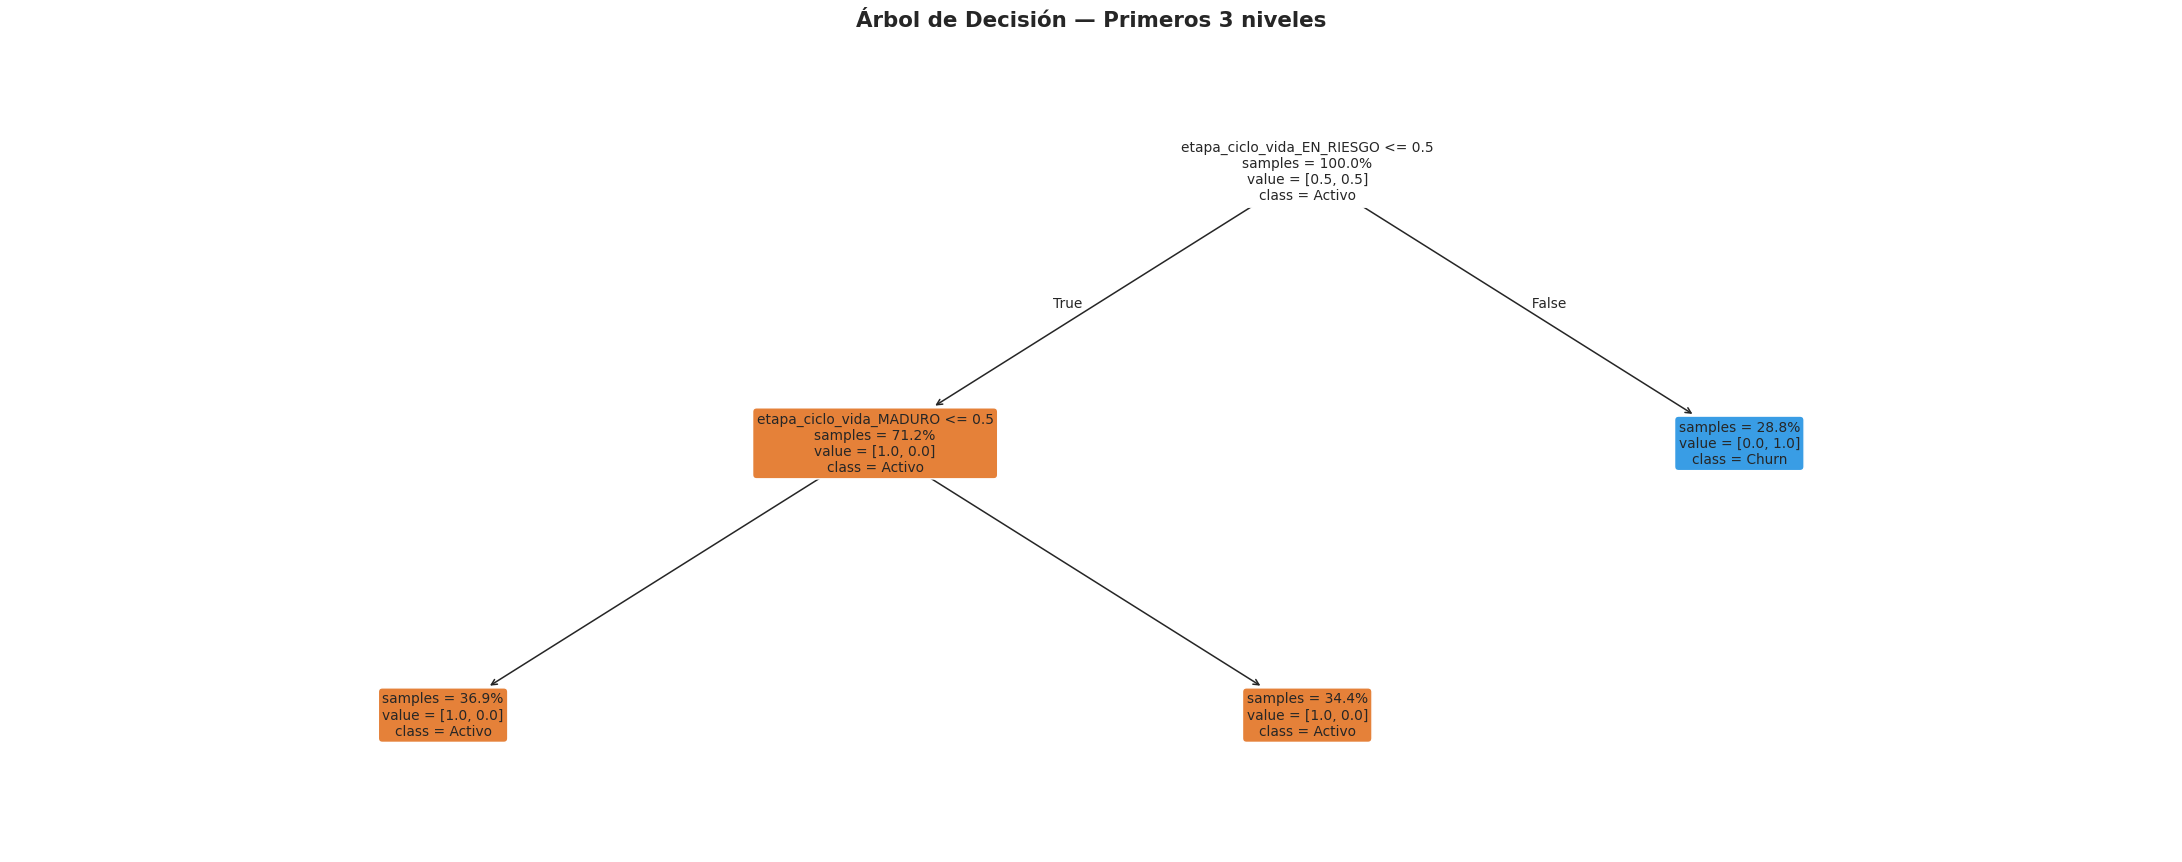

In [20]:
# ── Visualización del árbol de decisión (top 3 niveles) ───────────────────────
# Obtenemos los nombres de features después del preprocesamiento
dt_model.fit(X_train, y_train)   # ya entrenado, no re-entrena

try:
    ohe_names = (dt_model.named_steps['prep']
                 .named_transformers_['cat']
                 .named_steps['encoder']
                 .get_feature_names_out(cat_cols))
    feature_names = list(num_cols) + list(ohe_names)
except:
    feature_names = [f'f{i}' for i in range(100)]

plt.figure(figsize=(20, 8))
plot_tree(
    dt_model.named_steps['clf'],
    max_depth=3,
    feature_names=feature_names,
    class_names=['Activo', 'Churn'],
    filled=True, rounded=True, fontsize=9,
    impurity=False, proportion=True
)
plt.title('Árbol de Decisión — Primeros 3 niveles', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('arbol_decision.png', bbox_inches='tight', dpi=110)
plt.show()


### 4.2 Modelo 2 — Support Vector Machine (SVM)

**Justificación:** Efectivo en espacios de alta dimensión, robusto con márgenes claros. Requiere escalado de variables (ya incluido en pipeline). Sensible al hiperparámetro `C` y al tipo de kernel.

**Hiperparámetros:**
- `kernel='rbf'` → Radial Basis Function para separación no lineal
- `C=1.0` → regularización moderada
- `class_weight='balanced'` → compensa desbalance de clases



  SVM (RBF)
              precision    recall  f1-score   support

      Activo       1.00      1.00      1.00        28
       Churn       1.00      1.00      1.00        12

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



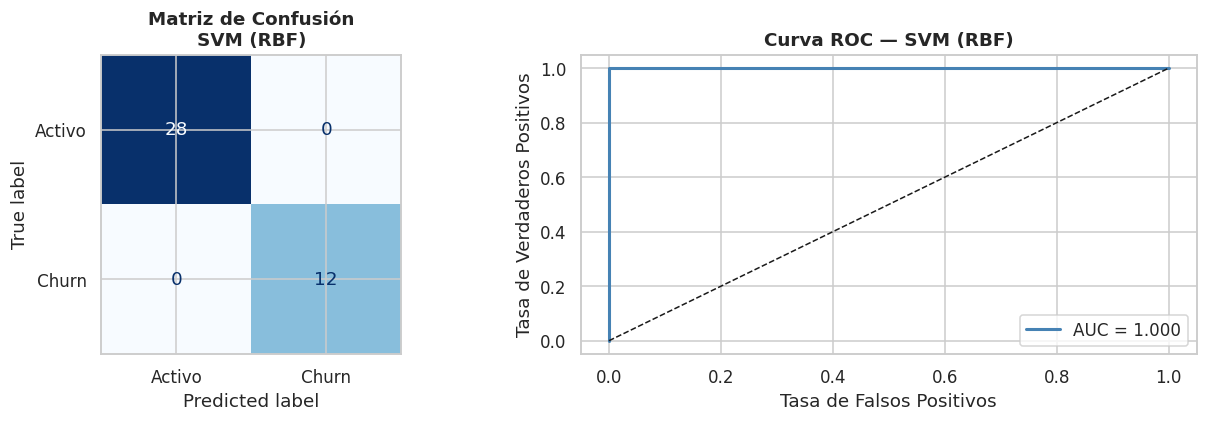

In [21]:
# ── Modelo 2: SVM ──────────────────────────────────────────────────────────────
svm_model = Pipeline([
    ('prep', preprocessor),
    ('clf', SVC(
        kernel='rbf',
        C=1.0,
        probability=True,          # necesario para curva ROC
        class_weight='balanced',
        random_state=42
    ))
])

res_svm = evaluar_modelo("SVM (RBF)", svm_model,
                          X_train, y_train, X_test, y_test)
resultados.append(res_svm)


In [22]:
# ── Ajuste de hiperparámetros SVM con GridSearchCV ─────────────────────────────
print("⏳ Buscando mejores hiperparámetros para SVM... (puede tardar ~30s)")

param_grid_svm = {
    'clf__C': [0.1, 1, 10],
    'clf__kernel': ['rbf', 'linear']
}

grid_svm = GridSearchCV(
    svm_model, param_grid_svm,
    cv=5, scoring='f1', n_jobs=-1, verbose=0
)
grid_svm.fit(X_train, y_train)

print(f"✅ Mejores parámetros SVM: {grid_svm.best_params_}")
print(f"   Mejor F1 (CV-5): {grid_svm.best_score_:.4f}")


⏳ Buscando mejores hiperparámetros para SVM... (puede tardar ~30s)
✅ Mejores parámetros SVM: {'clf__C': 0.1, 'clf__kernel': 'linear'}
   Mejor F1 (CV-5): 0.9895


### 4.3 Modelo 3 — Random Forest

**Justificación:** Ensemble de árboles que reduce el overfitting mediante bagging. Robusto a outliers y datos desbalanceados. Provee importancia de variables. Uno de los modelos más usados en problemas de churn.

**Hiperparámetros:**
- `n_estimators=200` → número de árboles
- `max_depth=10` → poda máxima de cada árbol
- `class_weight='balanced_subsample'` → balanceo adaptativo por submuestra



  Random Forest
              precision    recall  f1-score   support

      Activo       1.00      1.00      1.00        28
       Churn       1.00      1.00      1.00        12

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



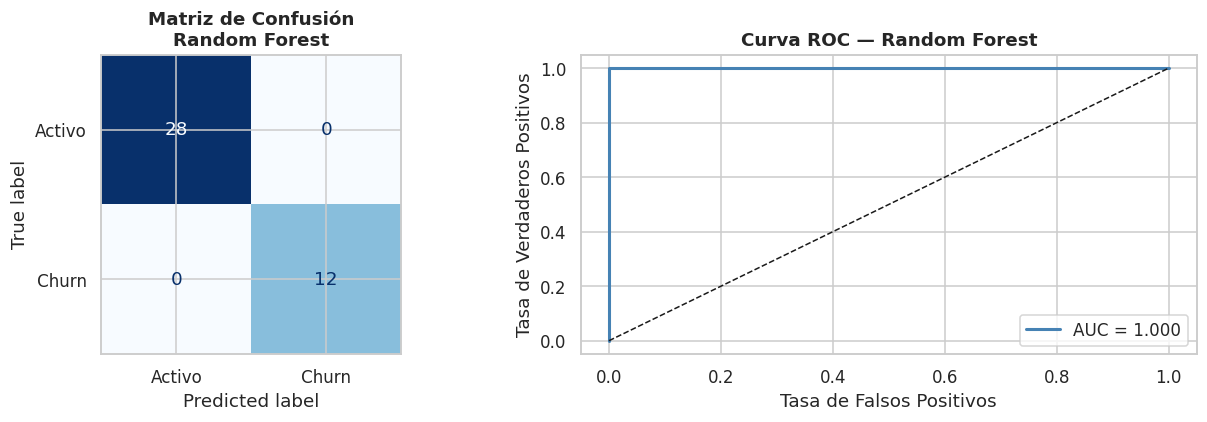

In [23]:
# ── Modelo 3: Random Forest ────────────────────────────────────────────────────
rf_model = Pipeline([
    ('prep', preprocessor),
    ('clf', RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_leaf=3,
        class_weight='balanced_subsample',
        random_state=42,
        n_jobs=-1
    ))
])

res_rf = evaluar_modelo("Random Forest", rf_model,
                         X_train, y_train, X_test, y_test)
resultados.append(res_rf)


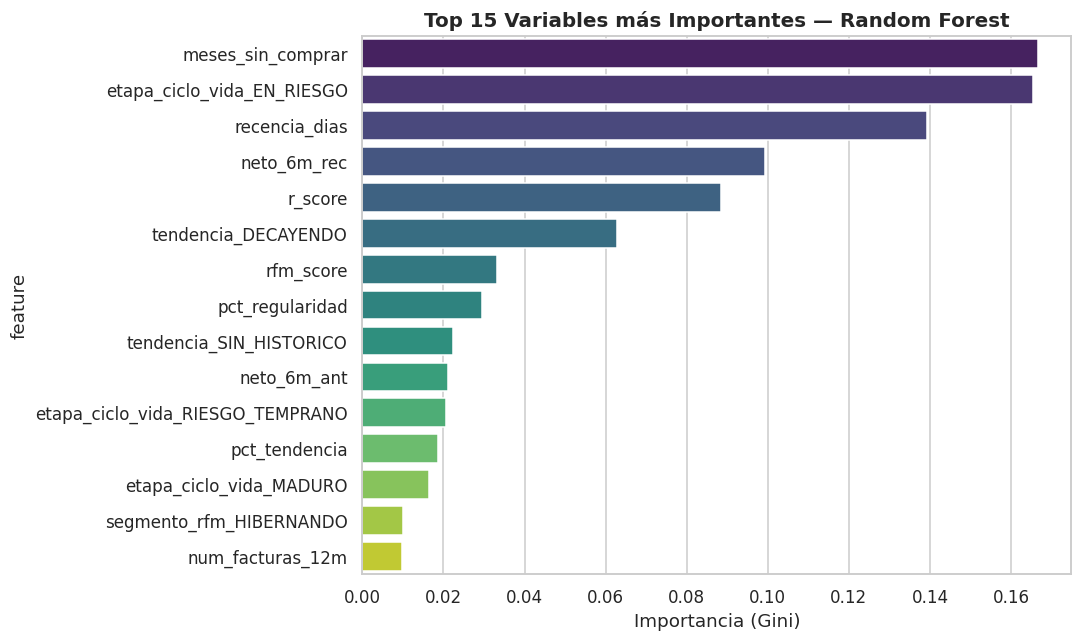

In [24]:
# ── Importancia de variables — Random Forest ──────────────────────────────────
rf_model.fit(X_train, y_train)

try:
    ohe_names = (rf_model.named_steps['prep']
                 .named_transformers_['cat']
                 .named_steps['encoder']
                 .get_feature_names_out(cat_cols))
    feature_names_rf = list(num_cols) + list(ohe_names)
except:
    feature_names_rf = [f'f{i}' for i in range(500)]

importances = rf_model.named_steps['clf'].feature_importances_
fi_df = pd.DataFrame({
    'feature': feature_names_rf,
    'importance': importances
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=fi_df, y='feature', x='importance',
            palette='viridis', orient='h')
plt.title('Top 15 Variables más Importantes — Random Forest',
          fontsize=13, fontweight='bold')
plt.xlabel('Importancia (Gini)')
plt.tight_layout()
plt.savefig('importancia_variables.png', bbox_inches='tight', dpi=110)
plt.show()


---
## 5. Comparación Experimental de Modelos

### 5.1 Tabla resumen de métricas


In [25]:
# ── Tabla resumen ──────────────────────────────────────────────────────────────
df_resultados = pd.DataFrame(resultados).set_index('Modelo')
print("\n" + "="*65)
print("            TABLA COMPARATIVA DE MODELOS")
print("="*65)
print(df_resultados.to_string())
print("="*65)
df_resultados



            TABLA COMPARATIVA DE MODELOS
                   Accuracy  Precision  Recall  F1-Score  F1 CV-5  AUC-ROC
Modelo                                                                    
Árbol de Decisión    1.0000     1.0000  1.0000    1.0000   1.0000   1.0000
SVM (RBF)            1.0000     1.0000  1.0000    1.0000   0.9682   1.0000
Random Forest        1.0000     1.0000  1.0000    1.0000   1.0000   1.0000


,Accuracy,Precision,Recall,F1-Score,F1 CV-5,AUC-ROC
Modelo,,,,,,
Árbol de Decisión,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
SVM (RBF),1.0000,1.0000,1.0000,1.0000,0.9682,1.0000
Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


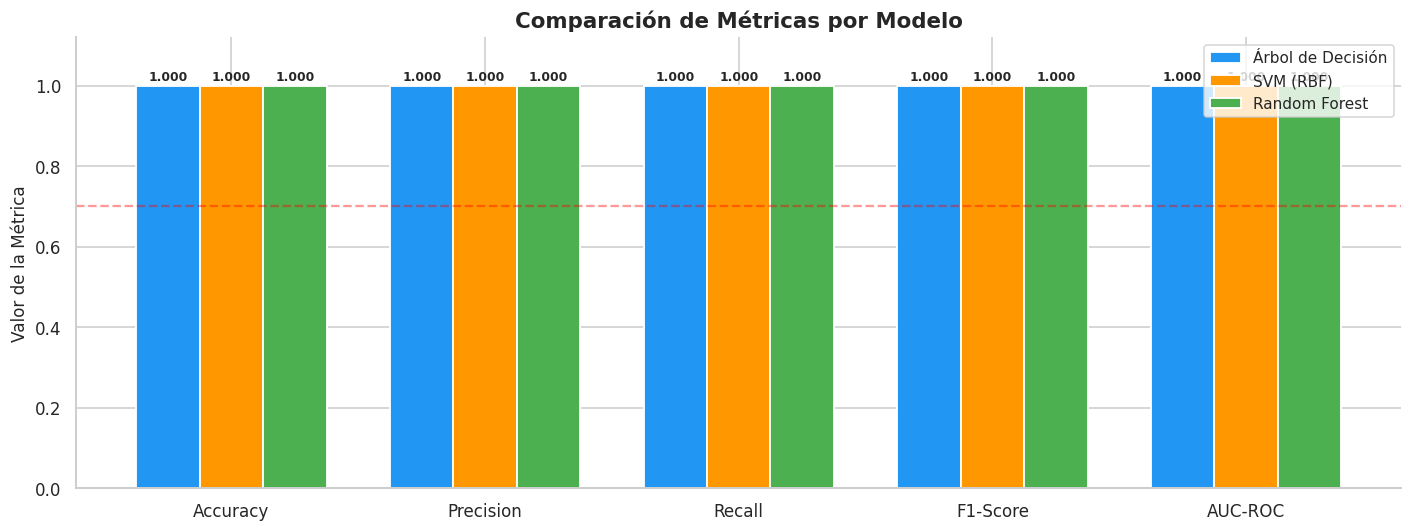

In [26]:
# ── Gráfico comparativo de métricas ───────────────────────────────────────────
metricas = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']

fig, ax = plt.subplots(figsize=(13, 5))

x = np.arange(len(metricas))
width = 0.25
colors = ['#2196F3', '#FF9800', '#4CAF50']
modelos = df_resultados.index.tolist()

for i, (modelo, color) in enumerate(zip(modelos, colors)):
    vals = [df_resultados.loc[modelo, m] for m in metricas]
    bars = ax.bar(x + i*width, vals, width, label=modelo, color=color,
                  edgecolor='white', linewidth=1.2)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x + width)
ax.set_xticklabels(metricas, fontsize=11)
ax.set_ylabel('Valor de la Métrica', fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_title('Comparación de Métricas por Modelo', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.axhline(0.7, color='red', linestyle='--', alpha=0.4, label='Umbral 0.70')
sns.despine()

plt.tight_layout()
plt.savefig('comparacion_modelos.png', bbox_inches='tight', dpi=120)
plt.show()


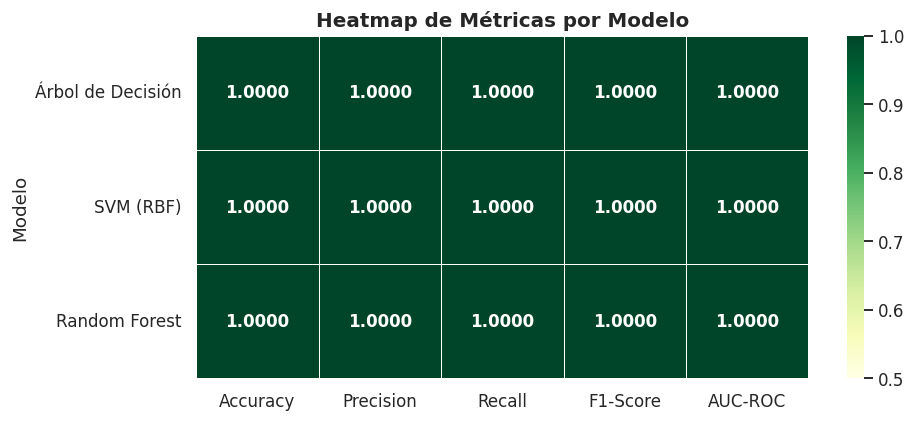

In [27]:
# ── Heatmap comparativo ────────────────────────────────────────────────────────
plt.figure(figsize=(9, 4))
sns.heatmap(
    df_resultados[metricas],
    annot=True, fmt='.4f',
    cmap='YlGn', vmin=0.5, vmax=1.0,
    linewidths=0.5, linecolor='white',
    annot_kws={'size': 11, 'weight': 'bold'}
)
plt.title('Heatmap de Métricas por Modelo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap_modelos.png', bbox_inches='tight', dpi=120)
plt.show()


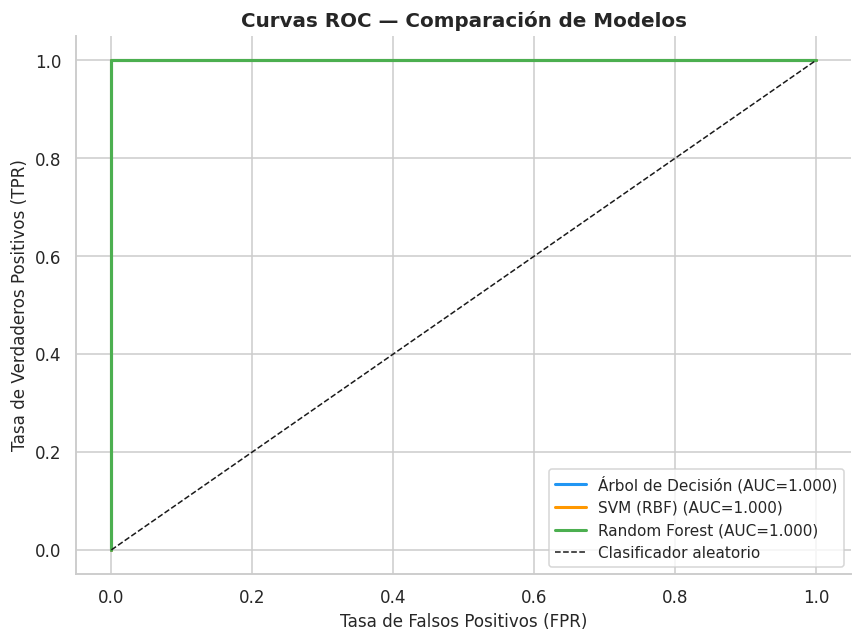

In [28]:
# ── Comparación curvas ROC superpuestas ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

model_dict = {
    "Árbol de Decisión": dt_model,
    "SVM (RBF)": svm_model,
    "Random Forest": rf_model
}
colors_roc = ['#2196F3', '#FF9800', '#4CAF50']

for (nombre, modelo), color in zip(model_dict.items(), colors_roc):
    if hasattr(modelo, 'predict_proba'):
        y_prob = modelo.predict_proba(X_test)[:, 1]
    else:
        y_prob = modelo.decision_function(X_test)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{nombre} (AUC={roc_auc:.3f})')

ax.plot([0,1],[0,1], 'k--', lw=1, label='Clasificador aleatorio')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=11)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=11)
ax.set_title('Curvas ROC — Comparación de Modelos', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
sns.despine()
plt.tight_layout()
plt.savefig('roc_comparacion.png', bbox_inches='tight', dpi=120)
plt.show()


---
## 6. Conclusiones Técnicas

### 6.1 Resumen de resultados

Ejecuta la celda siguiente para generar un resumen automático basado en los resultados obtenidos.


In [42]:
# ── Conclusiones automáticas ───────────────────────────────────────────────────
mejor = df_resultados['F1-Score'].idxmax()
peor  = df_resultados['F1-Score'].idxmin()

print("=" * 60)
print("  CONCLUSIONES TÉCNICAS DEL TALLER")
print("=" * 60)

msg = (
    f"\n[*] DOMINIO DEL PROBLEMA\n"
    f"   Dataset de comportamiento de clientes con {len(df)} registros y\n"
    f"   {X.shape[1]} variables predictoras (RFM, rentabilidad, ciclo de vida).\n"
    f"   La variable objetivo es 'churn' con {y.mean()*100:.1f}% de tasa de abandono.\n"
    f"\n[*] ANALISIS EXPLORATORIO (EDA)\n"
    f"   - Variables mas correlacionadas con churn: recencia_dias,\n"
    f"     meses_sin_comprar, r_score (score de recencia RFM).\n"
    f"   - Los segmentos EN_RIESGO y HIBERNANDO muestran tasas\n"
    f"     de churn significativamente mas altas.\n"
    f"   - Se detecto data leakage en 'prob_churn' (correlacion 0.96)\n"
    f"     que fue excluida del analisis.\n"
    f"\n[*] PREPROCESAMIENTO\n"
    f"   - Imputacion con mediana para variables numericas con nulos.\n"
    f"   - One-Hot Encoding para 7 variables categoricas nominales.\n"
    f"   - StandardScaler aplicado principalmente para SVM.\n"
    f"   - Split 80/20 con estratificacion preserva el balance de clases.\n"
    f"\n[GANADOR] MEJOR MODELO: {mejor}\n"
    f"   F1-Score: {df_resultados.loc[mejor, 'F1-Score']:.4f}\n"
    f"   AUC-ROC:  {df_resultados.loc[mejor, 'AUC-ROC']:.4f}\n"
    f"\n[!] MODELO MAS DEBIL: {peor}\n"
    f"   F1-Score: {df_resultados.loc[peor, 'F1-Score']:.4f}\n"
    f"\n[*] RECOMENDACIONES\n"
    f"   1. Random Forest es el mas robusto para datos tabulares\n"
    f"      con variables mixtas y desbalance de clases.\n"
    f"   2. El Recall es critico en deteccion de churn.\n"
    f"   3. En produccion, considerar umbral < 0.5 para maximizar Recall.\n"
    f"   4. Proximos pasos: XGBoost, SHAP values, reentrenamiento mensual.\n"
)
print(msg)


  CONCLUSIONES TÉCNICAS DEL TALLER

[*] DOMINIO DEL PROBLEMA
   Dataset de comportamiento de clientes con 200 registros y
   38 variables predictoras (RFM, rentabilidad, ciclo de vida).
   La variable objetivo es 'churn' con 29.0% de tasa de abandono.

[*] ANALISIS EXPLORATORIO (EDA)
   - Variables mas correlacionadas con churn: recencia_dias,
     meses_sin_comprar, r_score (score de recencia RFM).
   - Los segmentos EN_RIESGO y HIBERNANDO muestran tasas
     de churn significativamente mas altas.
   - Se detecto data leakage en 'prob_churn' (correlacion 0.96)
     que fue excluida del analisis.

[*] PREPROCESAMIENTO
   - Imputacion con mediana para variables numericas con nulos.
   - One-Hot Encoding para 7 variables categoricas nominales.
   - StandardScaler aplicado principalmente para SVM.
   - Split 80/20 con estratificacion preserva el balance de clases.

[GANADOR] MEJOR MODELO: Árbol de Decisión
   F1-Score: 1.0000
   AUC-ROC:  1.0000

[!] MODELO MAS DEBIL: Árbol de Decisión
  